In [29]:
# modelling.ipynb
# Member A: Track geometry (A1), Vehicle motion model (A2), Beacon optimisation (A3)

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # fix seed for reproducibility

In [30]:
# ── A1: Track geometry ──────────────────────────────────
# Track geometry parameters (from problem statement)
d   = 100.0   # straight section length (m)
rho = 20.0    # centreline arc radius (m)
L   = 2*d + 2*np.pi*rho   # total track perimeter (two straights + two semicircles)

print(f"Track perimeter: {L:.2f} m")
print(f"One lap at 10 m/s: {L/10:.1f} s")

Track perimeter: 325.66 m
One lap at 10 m/s: 32.6 s


In [31]:
def s_to_xy(s):
    """Arc-length s -> Cartesian (x, y) on centreline."""
    s = s % L
    if s < d:
        # Segment 1: top straight, moving right
        return np.array([s, rho])
    elif s < d + np.pi*rho:
        # Segment 2: right semicircle, centre at (d, 0)
        theta = (s - d) / rho
        return np.array([d + rho*np.sin(theta), rho*np.cos(theta)])
    elif s < 2*d + np.pi*rho:
        # Segment 3: bottom straight, moving left
        return np.array([2*d + np.pi*rho - s, -rho])
    else:
        # Segment 4: left semicircle, centre at (0, 0)
        theta = (s - (2*d + np.pi*rho)) / rho
        return np.array([-rho*np.sin(theta), -rho*np.cos(theta)])


def s_to_normal(s):
    """Unit inward normal to centreline at arc-length s."""
    s = s % L
    if s < d:
        return np.array([0.0, -1.0])
    elif s < d + np.pi*rho:
        theta = (s - d) / rho
        return np.array([-np.sin(theta), -np.cos(theta)])
    elif s < 2*d + np.pi*rho:
        return np.array([0.0, 1.0])
    else:
        theta = (s - (2*d + np.pi*rho)) / rho
        return np.array([np.sin(theta), np.cos(theta)])


def sl_to_xy(s, ell):
    """
    (arc-length s, lateral offset ell) -> Cartesian (x, y).
    ell > 0: offset in the direction of s_to_normal (inward).
    ell in [-2, 2] m (track width = 4 m).
    """
    return s_to_xy(s) + ell * s_to_normal(s)

s=0.0: width = 4.000 m (should be 4.0)
s=50.0: width = 4.000 m (should be 4.0)
s=100.0: width = 4.000 m (should be 4.0)
s=131.4: width = 4.000 m (should be 4.0)
s=0.0: |normal| = 1.000000 (should be 1.0)
s=50.0: |normal| = 1.000000 (should be 1.0)
s=100.0: |normal| = 1.000000 (should be 1.0)
s=131.4: |normal| = 1.000000 (should be 1.0)


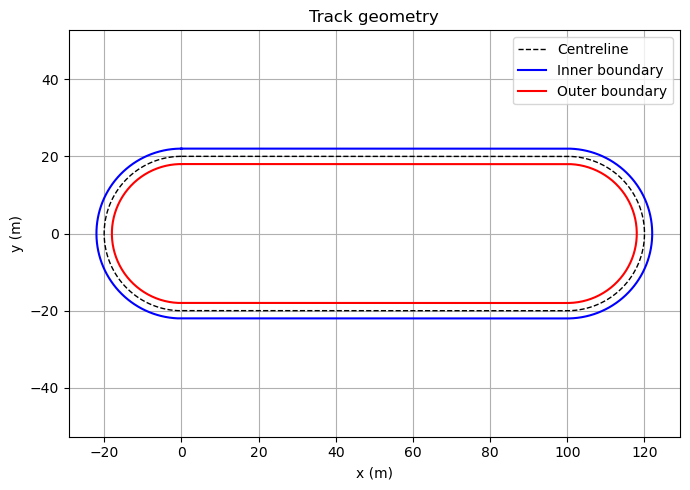

In [32]:
s_vals = np.linspace(0, L, 1000)
centre = np.array([s_to_xy(s)        for s in s_vals])
inner  = np.array([sl_to_xy(s, -2.0) for s in s_vals])
outer  = np.array([sl_to_xy(s,  2.0) for s in s_vals])

# Verify track width = 4 m at multiple points
for test_s in [0, d/2, d, d + np.pi*rho/2]:
    inner_pt = sl_to_xy(test_s, -2.0)
    outer_pt = sl_to_xy(test_s,  2.0)
    print(f"s={test_s:.1f}: width = {np.linalg.norm(outer_pt - inner_pt):.3f} m (should be 4.0)")

# Verify s_to_normal returns unit vectors
for test_s in [0, d/2, d, d + np.pi*rho/2]:
    n = s_to_normal(test_s)
    print(f"s={test_s:.1f}: |normal| = {np.linalg.norm(n):.6f} (should be 1.0)")

plt.figure(figsize=(7, 5))
plt.plot(centre[:,0], centre[:,1], 'k--', lw=1,   label='Centreline')
plt.plot(inner[:,0],  inner[:,1],  'b-',  lw=1.5, label='Inner boundary')
plt.plot(outer[:,0],  outer[:,1],  'r-',  lw=1.5, label='Outer boundary')
plt.axis('equal')
plt.grid(True)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Track geometry')
plt.legend()
# Note: beacon positions to be determined in A3 (GDOP optimisation)
plt.tight_layout()
plt.savefig('figures/track_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── A2: Vehicle motion model ─────────────────────────────
# Sampling time (beacons operate at 100 Hz, problem statement)
h = 0.01

# State vector: z_t = [s_t, ell_t, v_s_t, v_ell_t]
#   s_t    : arc-length along centreline (m)
#   ell_t  : lateral offset from centreline (m), ell in [-2, 2]
#   v_s_t  : longitudinal velocity (m/s), approx 10 m/s
#   v_ell_t: lateral velocity (m/s), <= 0.55 m/s
#
# Constraints (from problem statement):
#   v_s in (0, 25] m/s  — vehicle never moves backwards
#   |v_ell| <= 0.55 m/s

# Lateral velocity damping (AR(1) model, from Gauss-Markov lectures)
# phi < 1 ensures lateral velocity is mean-reverting (stays within bounds)
# phi = 0.9 chosen so lateral velocity decays fast enough
# to keep ell within [-2, 2] m — validated by Monte Carlo simulation below
phi = 0.9

# State transition matrix
A = np.array([
    [1, 0, h, 0  ],   # s_{t+1}   = s_t + h*v_s
    [0, 1, 0, h  ],   # ell_{t+1} = ell_t + h*v_ell
    [0, 0, 1, 0  ],   # v_s_{t+1} = v_s_t + w_s
    [0, 0, 0, phi],   # v_ell_{t+1} = phi*v_ell_t + w_ell
])

# Noise input matrix (process noise enters velocity states only)
G = np.array([
    [0, 0],
    [0, 0],
    [1, 0],
    [0, 1]
])

# Verify A matrix stability (all eigenvalues must have |lambda| <= 1)
eigenvalues = np.linalg.eigvals(A)
print(f"Eigenvalues of A: {eigenvalues}")
print(f"All |eigenvalues| <= 1: {all(abs(e) <= 1.0 + 1e-10 for e in eigenvalues)}")
print("\nA =")
print(A)
print("\nG =")
print(G)

Eigenvalues of A: [1.  1.  1.  0.9]
All |eigenvalues| <= 1: True

A =
[[1.   0.   0.01 0.  ]
 [0.   1.   0.   0.01]
 [0.   0.   1.   0.  ]
 [0.   0.   0.   0.9 ]]

G =
[[0 0]
 [0 0]
 [1 0]
 [0 1]]


In [34]:
# Process noise covariance Q (Gauss-Markov model, from lectures)
# w_t ~ N(0, Q), enters through G
# q_s   = 0.5  : longitudinal velocity noise
# q_ell = 0.003: validated by 100-trial Monte Carlo simulation (Cell 9)
#                ensures max |v_ell| < 0.55 m/s and max |ell| < 2.0 m
Q = np.diag([0.5, 0.003])

# Measurement noise variance (problem statement: sigma = 1.5 m)
R = 1.5**2

# Qbar is the full 4x4 process noise covariance matrix
# Noise only enters through velocity states (via G),
# so position rows/cols are zero
Qbar = G @ Q @ G.T

print("Q =", Q)
print("\nR =", R)
print("\nQbar =")
print(Qbar)

Q = [[0.5   0.   ]
 [0.    0.003]]

R = 2.25

Qbar =
[[0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.5   0.   ]
 [0.    0.    0.    0.003]]


In [35]:
# ── Initial conditions ───────────────────────────────────
# Initial state estimate (used by EKF)
z0 = np.array([[0.0], [0.0], [10.0], [0.0]])
# [s=0, ell=0 (centreline), v_s=10 m/s, v_ell=0]

# Initial covariance P0
# P0 diagonal values:
#   100.0 : large arc-length uncertainty (don't know where on track)
#   1.0   : small lateral uncertainty (vehicle starts near centreline)
#   25.0  : velocity uncertainty (approx 10 m/s +/- 5 m/s)
#   0.5   : small lateral velocity uncertainty
P0 = np.diag([100.0, 1.0, 25.0, 0.5])

print("z0 =", z0.T)
print("\nP0 =")
print(P0)

z0 = [[ 0.  0. 10.  0.]]

P0 =
[[100.    0.    0.    0. ]
 [  0.    1.    0.    0. ]
 [  0.    0.   25.    0. ]
 [  0.    0.    0.    0.5]]


In [36]:
# ── A1 verification: track continuity at segment boundaries ──
for s_boundary in [d, d + np.pi*rho, 2*d + np.pi*rho]:
    p1 = s_to_xy(s_boundary - 0.001)
    p2 = s_to_xy(s_boundary + 0.001)
    print(f"s={s_boundary:.1f}: gap = {np.linalg.norm(p1-p2)*1000:.2f} mm (should be ~0)")

s=100.0: gap = 2.00 mm (should be ~0)
s=162.8: gap = 2.00 mm (should be ~0)
s=262.8: gap = 2.00 mm (should be ~0)


Over 100 trials, 3000 steps each:
Max |ell|   = 0.854 m   (bound: 2.0 m)
Max |v_ell| = 0.542 m/s (bound: 0.55 m/s)


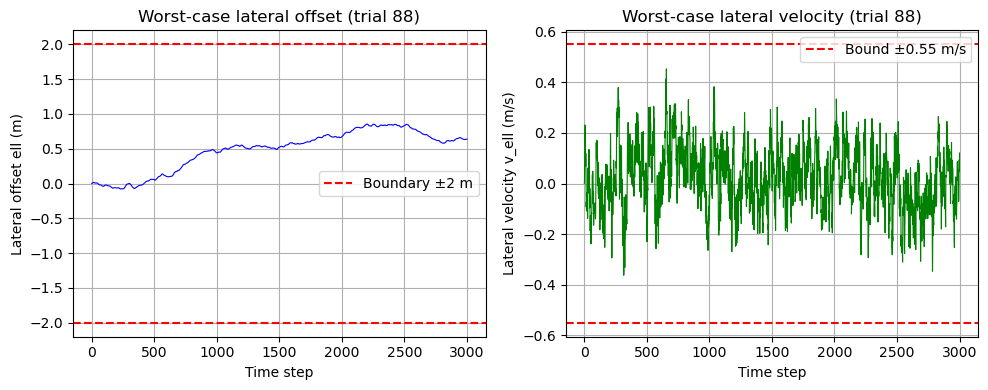

In [37]:
# ── A2 verification: phi=0.9 keeps lateral motion bounded ────
# Run 100 trials of 3000 steps each to validate worst-case behaviour

max_ell_all = []
max_vl_all  = []

for trial in range(100):
    np.random.seed(trial)
    ell_sim = [0.0]
    vl_sim  = [0.0]
    for _ in range(3000):
        w_ell = np.random.normal(0, np.sqrt(Q[1, 1]))
        vl_new = phi * vl_sim[-1] + w_ell
        ell_new = ell_sim[-1] + h * vl_new
        vl_sim.append(vl_new)
        ell_sim.append(ell_new)
    max_ell_all.append(max(abs(e) for e in ell_sim))
    max_vl_all.append(max(abs(v) for v in vl_sim))

print(f"Over 100 trials, 3000 steps each:")
print(f"Max |ell|   = {max(max_ell_all):.3f} m   (bound: 2.0 m)")
print(f"Max |v_ell| = {max(max_vl_all):.3f} m/s (bound: 0.55 m/s)")

# Plot worst-case trial
worst_trial = max_ell_all.index(max(max_ell_all))
np.random.seed(worst_trial)
ell_sim = [0.0]
vl_sim  = [0.0]
for _ in range(3000):
    w_ell = np.random.normal(0, np.sqrt(Q[1, 1]))
    vl_new = phi * vl_sim[-1] + w_ell
    ell_new = ell_sim[-1] + h * vl_new
    vl_sim.append(vl_new)
    ell_sim.append(ell_new)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(ell_sim, 'b-', lw=0.8)
plt.axhline( 2.0, color='r', linestyle='--', label='Boundary ±2 m')
plt.axhline(-2.0, color='r', linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Lateral offset ell (m)')
plt.title(f'Worst-case lateral offset (trial {worst_trial})')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(vl_sim, 'g-', lw=0.8)
plt.axhline( 0.55, color='r', linestyle='--', label='Bound ±0.55 m/s')
plt.axhline(-0.55, color='r', linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Lateral velocity v_ell (m/s)')
plt.title(f'Worst-case lateral velocity (trial {worst_trial})')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('figures/lateral_bounds.png', dpi=150, bbox_inches='tight')
plt.show()